### Phase 2 Implementation

In [39]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_openrouter import ChatOpenRouter
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing_extensions import Annotated,TypedDict
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_tavily import tavily_search
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.document_loaders import WebBaseLoader
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage
from langchain_core.tools import tool
import os

In [40]:
MODELS = {
    "planner": "qwen/qwen3.6-27b",
    "researcher": "nvidia/nemotron-3-ultra-550b-a55b:free",
    "writer": "qwen/qwen3.6-27b"
}

In [41]:
load_dotenv(override=True) 
memory=MemorySaver()
planner_llm = init_chat_model(
    model=MODELS["planner"],
    model_provider="groq"
)

researcher_llm = init_chat_model(
    model=MODELS["researcher"],
    model_provider="openrouter"
)

writer_llm = init_chat_model(
    model=MODELS["writer"],
    model_provider="groq",
    reasoning_format="hidden"
)


In [42]:
class State(TypedDict):
    messages: Annotated[list,add_messages]
    research_messages:list
    plan:list[str]
    findings:list[dict]
    current_task:int
    tool_rounds:int
    report:str

In [43]:
DEV_CONFIG = {

    # planner
    "max_tasks": 3,

    # researcher
    "max_finding_words": 120,
    "max_search_results": 3,
    "max_tool_rounds": 1,

    # writer
    "max_report_words": 1000,

    # debugging
    "show_logs": True,

}

In [44]:

from langchain_tavily import TavilySearch


tavily_tool=TavilySearch(max_results=3)

arxiv = ArxivQueryRun(
    api_wrapper=ArxivAPIWrapper()
)
from langchain_core.tools import tool


tools=[tavily_tool]
researcher_with_tools=researcher_llm.bind_tools(tools)

PLANNER_PROMPT = """
You are a research planner.

Your job is to break a user query into research tasks.

Rules:

- Create the minimum number of tasks required.
- Avoid overlapping tasks.
- Each task should investigate a different aspect.
- Every task must be self-contained.
- Every task must explicitly include the subject being researched.
- Never create generic tasks.

Bad examples:
[
"Compare architecture",
"Compare use cases",
"Compare strengths"
]

Good examples:
[
"Compare LangGraph and CrewAI architecture",
"Compare LangGraph and CrewAI use cases",
"Compare LangGraph and CrewAI strengths and weaknesses"
]

For simple factual questions:
Create 1 task.

For comparison questions:
Create 3-5 tasks.

For deep research:
Create as many tasks as necessary.

Return ONLY a Python list.

Examples:

User:
What is LangGraph?

Output:
[
"What is LangGraph?"
]

User:
Compare LangGraph and CrewAI

Output:
[
"Compare LangGraph and CrewAI architecture",
"Compare LangGraph and CrewAI strengths and weaknesses",
"Compare LangGraph and CrewAI use cases"
]
"""
RESEARCHER_PROMPT = """
You are a research specialist.

Research ONE task.

Rules:

- Use tools whenever external information is needed.
- Read tool results carefully.
- Extract only the most relevant information.
- Synthesize information from multiple sources.
- Focus only on the assigned task.
- Do not write a report.
- Do not write introductions.
- Do not write conclusions.
- Do not create sections.
- Do not copy source text.
- If evidence is insufficient, explicitly state what is missing.

Output:
- Finding 1
- Finding 2
- Finding 3
- Finding 4

Maximum {max_finding_words} words.
"""
import ast
import re
def planner(state: State):
    user_query = state["messages"][-1].content

    response = planner_llm.invoke([
        SystemMessage(content=PLANNER_PROMPT),
        HumanMessage(content=user_query)
    ])
    content = response.content

    if "</think>" in content:
        content = content.split("</think>")[-1].strip()

    # Extract the Python list even if the model added extra text around it
    list_match = re.search(r'\[.*\]', content, re.DOTALL)
    if list_match:
        content = list_match.group(0)

    plan = ast.literal_eval(content)

    result = {
        "plan": plan,
        "current_task": 0
    }
    print(result)

    return result

def prepare_task(state:State):
    task = state["plan"][state["current_task"]]
    print(
    "PREPARE TASK LENGTH:",
    len(state.get("research_messages", []))
)
    return{
        "research_messages":[SystemMessage(content=RESEARCHER_PROMPT),
        HumanMessage(content=task)],
        "tool_rounds": 0
    }
    
def researcher(state: State):

    print("\n===== RESEARCHER =====")

    response = researcher_with_tools.invoke(
        state["research_messages"]
    )

    # Tool call case
    if response.tool_calls:
        print("\nTOOL CALLS:")
        print(response.tool_calls)

        # Strip thinking tokens from tool-call responses to save context
        from langchain_core.messages import AIMessage as _AIMsg
        clean = _AIMsg(content="", tool_calls=response.tool_calls)

        return {
            "research_messages":
            state["research_messages"] + [clean],
            "tool_rounds": state.get("tool_rounds", 0) + 1
        }

    # Normal text case
    content = response.content

    if "</think>" in content:
        content = content.split("</think>")[-1].strip()

    #content = content[:DEV_CONFIG["max_finding_chars"]]

    clean_response = AIMessage(content=content)

    print("\nCONTENT:")
    print(repr(content))

    return {
        "research_messages":
        state["research_messages"] + [clean_response]
    }
def research_router(state: State):

    last_message = state["research_messages"][-1]
    max_tool_rounds = DEV_CONFIG.get("max_tool_rounds", 1)

    print("\n===== ROUTER =====")
    print(type(last_message))
    print(f"Tool rounds: {state.get('tool_rounds', 0)}/{max_tool_rounds}")
    print(getattr(last_message, "tool_calls", None))

    # Hard cap: if we've already done max rounds, force synthesis
    if state.get("tool_rounds", 0) >= max_tool_rounds:
        print("MAX TOOL ROUNDS REACHED - forcing synthesize")
        return "synthesize"

    if (
        hasattr(last_message, "tool_calls")
        and len(last_message.tool_calls) > 0
    ):
        print("GO TO TOOLS")
        return "tools"

    print("GO TO SAVE_FINDING")
    return "save_finding"
def synthesize(state: State):
    """Force the researcher to synthesize findings when tool cap is reached."""
    print("\n===== SYNTHESIZE (forced) =====")

    task = state["plan"][state["current_task"]]
    synthesis_prompt = f"""Based on the search results above, synthesize your findings for this task: {task}

Output ONLY bullet points. Maximum {DEV_CONFIG['max_finding_words']} words. Do not use tools."""

    # Call LLM without tools so it can only produce text (with retry for connection drops)
    messages = state["research_messages"] + [HumanMessage(content=synthesis_prompt)]
    import time
    content = ""
    for attempt in range(3):
        try:
            response = researcher_llm.invoke(messages)
            content = response.content
            break
        except Exception as e:
            print(f"SYNTHESIZE attempt {attempt+1} failed: {e}")
            if attempt < 2:
                time.sleep(2)
            else:
                raise

    if "</think>" in content:
        content = content.split("</think>")[-1].strip()

    print("SYNTHESIZED:", repr(content[:200]))
    clean_response = AIMessage(content=content)

    return {
        "research_messages": state["research_messages"] + [clean_response]
    }
def save_finding(state: State):
    task = state["plan"][state["current_task"]]
    final_answer = state["research_messages"][-1].content

    finding = {
        "task": task,
        "content": final_answer,
    }

    return {
        "findings": state["findings"] + [finding],
        "current_task": state["current_task"] + 1,
        "research_messages": []
    }

def router(state:State):
    if(state["current_task"]<len(state["plan"])):
        return "prepare_task"
    return "writer"

WRITER_PROMPT = """
You are an expert report writer.

You will receive multiple research findings.

Create a coherent report using ONLY those findings.

Rules:

- Do not invent information.
- Do not include chain-of-thought.
- Do not mention missing information unless present in findings.
- Synthesize findings into a readable report.
- Avoid repetition.

Format:

# Title

## Overview

## Key Findings

## Analysis

## Conclusion
"""

def writer(state: State):
    print("\n===== WRITER =====")
    print("FINDINGS COUNT:", len(state["findings"]))

    for i, item in enumerate(state["findings"], start=1):
        print(f"\n--- FINDING {i} ---")
        print("TASK:", item["task"])
        print("CHARS:", len(item["content"]))
        print(item["content"][:])

    findings_text = "\n\n".join(
        f"TASK: {item['task']}\n\n{item['content']}"
        for item in state["findings"]
    )

    response = writer_llm.invoke([
        SystemMessage(content=WRITER_PROMPT),
        HumanMessage(content=f"Research Findings:\n\n{findings_text}")
    ])

    report = response.content
    print("WRITER RAW RESPONSE LENGTH:", len(report))
    print("WRITER RAW FIRST 200:", repr(report[:200]))
    if "</think>" in report:
        stripped = report.split("</think>")[-1].strip()
        # If everything was inside think tags, keep the thinking content as fallback
        report = stripped if stripped else report.split("</think>")[0].replace("<think>", "").strip()
    print("WRITER FINAL LENGTH:", len(report))

    return {
        "report": report
    }
tool_node=ToolNode(tools)

def tools_wrapper(state:State):
    print("TOOLS WRAPPER CALLED")
    result = tool_node.invoke(
        {
        "messages":state["research_messages"]
        }
    )
    return {
        "research_messages":state["research_messages"]+[result["messages"][-1]]
    }

In [45]:
builder=StateGraph(State)
builder.add_node("planner", planner)
builder.add_node("prepare_task",prepare_task)
builder.add_node("save_finding",save_finding)
builder.add_node("researcher", researcher)
builder.add_node("synthesize", synthesize)
builder.add_node("writer", writer)
builder.add_node("tools",tools_wrapper)

builder.add_edge(START, "planner")
builder.add_edge("planner", "prepare_task")
builder.add_edge("prepare_task","researcher")
builder.add_conditional_edges(
    "researcher",
    research_router,
    {
        "tools": "tools",
        "save_finding": "save_finding",
        "synthesize": "synthesize"
    }
)
builder.add_edge(
    "tools",
    "researcher"
)
builder.add_edge("synthesize", "save_finding")
builder.add_conditional_edges(
    "save_finding",
    router,
    {
        "prepare_task": "prepare_task",
        "writer": "writer"
    }
)
builder.add_edge("writer", END)
graph=builder.compile(checkpointer=memory)

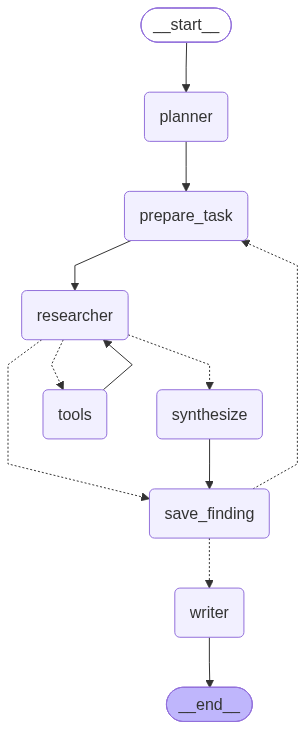

In [46]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [49]:
config = {
    "configurable": {
        "thread_id": "researchflow8"
    }
}

In [51]:
print("\n\n===== FINAL OUTPUT =====\n")
print(result["report"])



===== FINAL OUTPUT =====


